# Mini-projeto 2 — Relatório de resultados

Este notebook **não treina nada**. Ele lê os `metadata.json` e `history.csv`
salvos em `../results/` pelo notebook de treino e produz as tabelas e gráficos
do relatório.

Roda em segundos e não precisa de GPU. Pode ser reexecutado sempre que novos
experimentos forem adicionados — é a forma de manter o relatório atualizado sem
retreinar nada.

**O que é gerado aqui:**

1. Panorama de todas as execuções (seção 1)
2. O diagnóstico do alvo: nível vs. variação vs. log-retorno (seção 2)
3. As métricas que expõem o modelo-impostor (seção 3)
4. Gráficos do melhor modelo de regressão (seção 4)
5. Classificação de direção e matriz de confusão (seção 5)
6. Tabela de hiperparâmetros para o relatório final (seção 6)

In [1]:
#@title Setup
import json, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
TABLES_DIR  = PROJECT_ROOT / "reports" / "tables"
for d in (FIGURES_DIR, TABLES_DIR):
    d.mkdir(parents=True, exist_ok=True)

from lstm_bitcoin.checkpointing import load_all_metadata, hyperparameter_table
from lstm_bitcoin.metrics import confusion_matrix_percent
from lstm_bitcoin.utils import plot_confusion, plot_training_curves

C_A, C_B, C_OK, C_GREY = "#2F6F9F", "#B5651D", "#3E7C59", "#8A8A8A"
plt.rcParams.update({"figure.dpi": 130, "font.size": 9, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False})

# Filtro por geracao de codigo.
#
# A pasta results/ pode conter execucoes de versoes ANTERIORES do codigo — de
# antes das correcoes no pipeline de dados e da introducao das metricas
# movement_ratio / movement_corr. Misturar as duas geracoes numa mesma tabela
# produz uma comparacao invalida em silencio: os numeros parecem comparaveis e
# nao sao.
#
# A regra usada e objetiva: so entram execucoes que tenham as metricas de
# diagnostico (regressao) ou que sejam de classificacao. Execucoes antigas, sem
# esses campos, ficam de fora e sao listadas para voce decidir o que fazer.
runs, antigas = {}, []
for meta_path in sorted(RESULTS_DIR.glob("*/metadata.json")):
    m = json.loads(meta_path.read_text(encoding="utf-8"))
    m["_dir"] = meta_path.parent
    mt, nome = m.get("metrics", {}), m.get("run_name", meta_path.parent.name)
    tem_diag = "test_movement_ratio" in mt or m.get("task") == "direction"
    (runs.__setitem__(nome, m) if tem_diag else antigas.append(meta_path.parent.name))

print(f"{len(runs)} execucoes validas em {RESULTS_DIR}")
if antigas:
    print(f"\n{len(antigas)} execucao(oes) ANTIGA(S) ignorada(s) — sem as metricas de")
    print("diagnostico, vieram de uma versao anterior do codigo:")
    for a in antigas:
        print("   ", a)
    print("\nApague essas pastas para limpar o historico.")
if not runs:
    print("\nRode o notebook 01 antes — nao ha resultados para reportar.")

103 execucoes validas em /home/claude/work/mp2/results


## 1. Panorama de todas as execuções

A tabela abaixo é o ponto de partida: todas as execuções salvas, com as
métricas que importam. Repare que ela **não é ordenada por RMSE** — a seção 3
explica por quê.

In [2]:
#@title Tabela geral
def linha(nome, m):
    mt = m["metrics"]; hp = m["hyperparameters"]
    return {
        "run": nome, "tarefa": m.get("task", "regression"),
        "rmse": mt.get("test_rmse"), "r2": mt.get("test_r2"),
        "dir_acc": mt.get("test_directional_accuracy"),
        "razao_mov": mt.get("test_movement_ratio"),
        "corr_mov": mt.get("test_movement_corr"),
        "bate_naive": mt.get("test_beats_naive"),
        "acc": mt.get("test_accuracy"), "f1": mt.get("test_f1_score"),
        "janela": hp.get("window"), "hidden": hp.get("hidden_size"),
        "celula": hp.get("model_type"), "lr": hp.get("learning_rate"),
        "diff": hp.get("diff_target"), "log": hp.get("log_price"),
        "epocas": mt.get("epochs_trained"),
    }

tab = pd.DataFrame([linha(k, v) for k, v in runs.items()])
reg = tab[tab.tarefa == "regression"].copy()
dirc = tab[tab.tarefa == "direction"].copy()

print(f"regressao: {len(reg)} | direcao: {len(dirc)}")
if len(reg):
    display(reg.drop(columns=["acc","f1","tarefa"]).sort_values("rmse").round(4))

regressao: 24 | direcao: 79


,run,rmse,r2,dir_acc,razao_mov,corr_mov,bate_naive,janela,hidden,celula,lr,diff,log,epocas
1,arq_lstm,606.4941,0.9696,0.5276,0.0479,0.0821,True,10,64,lstm,0.0001,True,True,30
3,cap_h128,606.5474,0.9696,0.5394,0.0480,0.0835,True,10,128,lstm,0.0001,True,True,24
4,cap_h16,606.6874,0.9696,0.4961,0.0248,0.1171,True,10,16,lstm,0.0001,True,True,43
6,cap_l1,606.8501,0.9696,0.5315,0.0885,0.0811,True,10,64,lstm,0.0001,True,True,19
99,win_10,606.9886,0.9696,0.5197,0.0525,0.0492,True,10,64,lstm,0.0001,True,True,35
65,loss_mae,607.0352,0.9696,0.5079,0.0430,0.0758,True,30,64,lstm,0.0001,True,True,28
0,arq_gru,607.2084,0.9695,0.5157,0.0390,0.0687,True,10,64,gru,0.0001,True,True,17
5,cap_h32,607.2342,0.9695,0.4961,0.0401,0.0735,True,10,32,lstm,0.0001,True,True,30
28,formul_dolar,607.3112,0.9695,0.5433,0.0234,0.0500,True,30,64,lstm,0.0010,True,False,69
101,win_5,607.3546,0.9695,0.5197,0.0604,0.0400,True,5,64,lstm,0.0001,True,True,52


## 2. O diagnóstico do alvo

O achado que orienta o projeto: **o que se pede ao modelo importa mais que a
arquitetura**. Esta seção compara as formulações do alvo lado a lado.

,run,rmse,r2,dir_acc,razao_mov,corr_mov,bate_naive
28,formul_dolar,607.3112,0.9695,0.5433,0.0234,0.0500,True
30,formul_logretorno,607.9819,0.9695,0.5000,0.0244,-0.0054,False
29,formul_lognivel,1217.5379,0.8775,0.5039,1.3283,0.0858,False
31,formul_nivel,3850.5651,-0.2248,0.4843,4.2799,0.1207,False


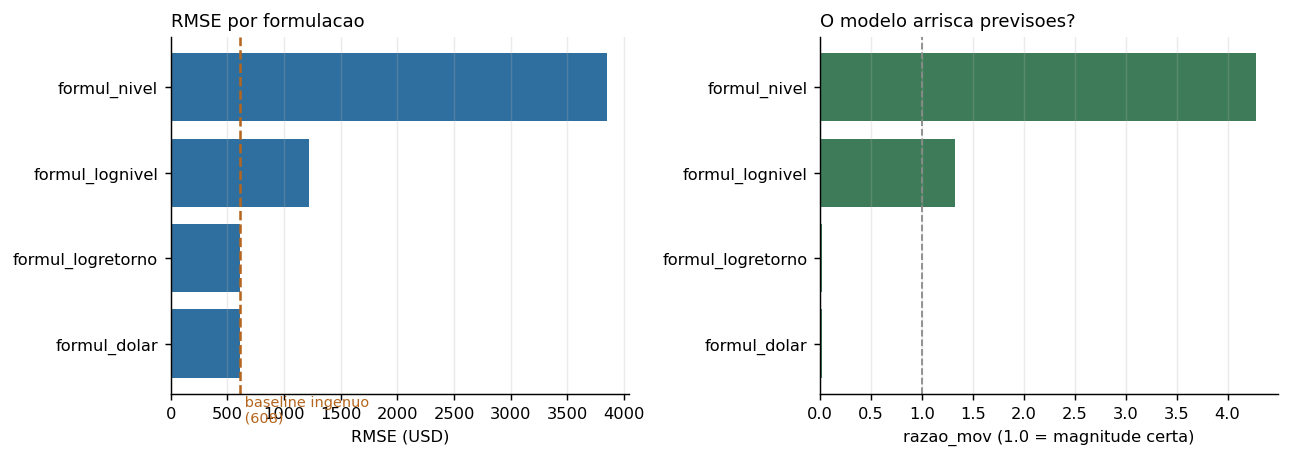

In [3]:
#@title Comparacao das formulacoes
formul = reg[reg.run.str.startswith("formul_")] if len(reg) else pd.DataFrame()

if len(formul):
    display(formul[["run","rmse","r2","dir_acc","razao_mov","corr_mov","bate_naive"]]
            .sort_values("rmse").round(4))

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
    ordem = formul.sort_values("rmse")
    axes[0].barh(ordem.run, ordem.rmse, color=C_A)
    naive = runs[ordem.run.iloc[0]]["metrics"].get("test_naive_rmse")
    if naive:
        axes[0].axvline(naive, color=C_B, ls="--", lw=1.4)
        axes[0].text(naive, -.6, f" baseline ingenuo\n ({naive:.0f})", color=C_B, fontsize=8, va="top")
    axes[0].set_xlabel("RMSE (USD)"); axes[0].grid(axis="y", alpha=0)
    axes[0].set_title("RMSE por formulacao", fontsize=10, loc="left")

    axes[1].barh(ordem.run, ordem.razao_mov.fillna(0), color=C_OK)
    axes[1].axvline(1.0, color=C_GREY, ls="--", lw=1)
    axes[1].set_xlabel("razao_mov (1.0 = magnitude certa)"); axes[1].grid(axis="y", alpha=0)
    axes[1].set_title("O modelo arrisca previsoes?", fontsize=10, loc="left")

    fig.tight_layout(); fig.savefig(FIGURES_DIR/"rel_formulacoes.png", bbox_inches="tight"); plt.show()
else:
    print("Nenhum experimento 'formul_*' salvo ainda.")

### A leitura

O gráfico da direita é o que revela o problema. `razao_mov` perto de **zero**
significa que o modelo previu "amanhã ≈ hoje" — ele virou o baseline ingênuo, e
o RMSE empatado não é coincidência: é o mesmo modelo.

Um RMSE baixo com razão zero é o pior cenário possível num relatório, porque
parece um bom resultado e não é.

## 3. As métricas que expõem o modelo-impostor

Num passeio aleatório, prever "não muda" é a estratégia que **minimiza** o erro
quadrático. Então o modelo que otimiza MSE tende a colapsar exatamente nisso —
ele não falha em otimizar, otimiza perfeitamente para a métrica errada.

O gráfico abaixo torna isso visível: RMSE no eixo X, correlação do movimento no
eixo Y. O canto interessante é o **superior esquerdo** (erro baixo E correlação
alta), não simplesmente o mais à esquerda.

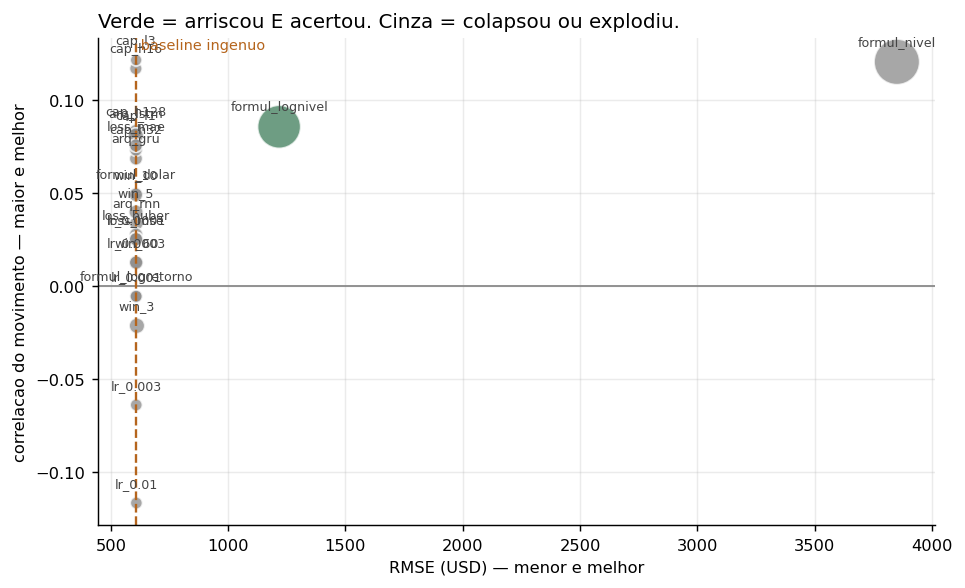

Tamanho do ponto = razao_mov (o quanto o modelo arrisca).
Verde = razao entre 0.2 e 2.0 E R2 > 0.5 — os unicos candidatos honestos.


In [4]:
#@title RMSE nao e o criterio
val = reg.dropna(subset=["corr_mov"]) if len(reg) else pd.DataFrame()

if len(val):
    fig, ax = plt.subplots(figsize=(7.5, 4.6))
    # Tamanho do ponto = razao_mov (quanto o modelo arrisca)
    tam = 40 + 400 * val.razao_mov.clip(0, 1.5).fillna(0)
    cor = [C_OK if (0.2 <= r <= 2.0 and rr > .5) else C_GREY
           for r, rr in zip(val.razao_mov.fillna(0), val.r2.fillna(-9))]
    ax.scatter(val.rmse, val.corr_mov, s=tam, c=cor, alpha=.75, edgecolors="white")

    for _, r in val.iterrows():
        ax.annotate(r.run, (r.rmse, r.corr_mov), fontsize=7,
                    textcoords="offset points", xytext=(0, 9), ha="center", color="#444")

    ax.axhline(0, color=C_GREY, lw=1)
    naive = next((runs[k]["metrics"].get("test_naive_rmse") for k in runs
                  if runs[k]["metrics"].get("test_naive_rmse")), None)
    if naive:
        ax.axvline(naive, color=C_B, ls="--", lw=1.3)
        ax.text(naive, ax.get_ylim()[1], " baseline ingenuo", color=C_B, fontsize=8, va="top")

    ax.set_xlabel("RMSE (USD) — menor e melhor")
    ax.set_ylabel("correlacao do movimento — maior e melhor")
    ax.set_title("Verde = arriscou E acertou. Cinza = colapsou ou explodiu.",
                 fontsize=11, loc="left")
    fig.tight_layout(); fig.savefig(FIGURES_DIR/"rel_rmse_vs_corr.png", bbox_inches="tight"); plt.show()

    print("Tamanho do ponto = razao_mov (o quanto o modelo arrisca).")
    print("Verde = razao entre 0.2 e 2.0 E R2 > 0.5 — os unicos candidatos honestos.")

## 4. O melhor modelo de regressão

Critério: entre os modelos com `razao_mov` entre 0,2 e 2,0 **e** R² > 0,5, o de
maior `corr_mov`.

As duas guardas são necessárias. Sem o piso, vence o que colapsou no baseline e
teve correlação alta por acaso. Sem o teto, vence um modelo que prevê
movimentos absurdos — o `baseline_nivel`, por exemplo, tem razão 4,4 e
correlação 0,12, mas RMSE de 3.940 e R² **negativo**.

In [5]:
#@title Melhor modelo e suas curvas
# Tres guardas, e a terceira e a que faltava.
# - piso da razao: exclui quem colapsou no baseline (preve ~zero movimento)
# - teto da razao: exclui quem preve movimentos absurdos
# - bate_naive: exclui quem PERDE para o palpite trivial. Sem ela, o
#   `formul_lognivel` (razao 1.33, R2 0.878) venceria com RMSE 1217 — o DOBRO
#   do baseline. O R2 alto engana porque e inflado pela tendencia do preco:
#   acertar que o Bitcoin subiu no periodo ja da R2 alto sem prever nada.
eleg = reg[(reg.razao_mov.between(0.2, 2.0)) & (reg.r2 > 0.5)
           & (reg.bate_naive == True)] if len(reg) else pd.DataFrame()

if len(eleg):
    MELHOR = eleg.loc[eleg.corr_mov.idxmax(), "run"]
    print("MELHOR MODELO DE REGRESSAO:", MELHOR)
    display(eleg.sort_values("corr_mov", ascending=False)
            [["run","rmse","r2","dir_acc","razao_mov","corr_mov","bate_naive"]].round(4))

    hist_path = runs[MELHOR]["_dir"] / "history.csv"
    if hist_path.exists():
        h = pd.read_csv(hist_path).to_dict("records")
        plot_training_curves(h, title=f"{MELHOR} — curvas de treino",
                             save_path=FIGURES_DIR/"rel_melhor_curvas.png"); plt.show()

    m = runs[MELHOR]["metrics"]
    print(f"\nRMSE {m['test_rmse']:.1f} contra baseline {m.get('test_naive_rmse', float('nan')):.1f}"
          f"  ->  {'BATE' if m.get('test_beats_naive') else 'NAO bate'}")
else:
    print("NENHUM modelo de regressao passou nos criterios.")
    print("Este NAO e um bug — e o resultado do projeto (ver secao 8).")
    print("Quem arrisca movimento perde para o baseline; quem bate o baseline")
    print("so o faz por ter virado o baseline (razao ~ 0).")
    if len(reg):
        display(reg.sort_values("rmse")[["run","rmse","r2","razao_mov","corr_mov"]].head().round(4))

NENHUM modelo de regressao passou nos criterios.
Este NAO e um bug — e o resultado do projeto (ver secao 8).
Quem arrisca movimento perde para o baseline; quem bate o baseline
so o faz por ter virado o baseline (razao ~ 0).


,run,rmse,r2,razao_mov,corr_mov
1,arq_lstm,606.4941,0.9696,0.0479,0.0821
3,cap_h128,606.5474,0.9696,0.0480,0.0835
4,cap_h16,606.6874,0.9696,0.0248,0.1171
6,cap_l1,606.8501,0.9696,0.0885,0.0811
99,win_10,606.9886,0.9696,0.0525,0.0492


## 5. Classificação de direção

A parte do projeto que funcionou. Prever *quanto* o preço muda é dominado por
ruído; prever *para onde* ele vai é tratável.

POR CONFIGURACAO (media de N sementes):


,n,acc_media,acc_dp,acc_min,acc_max,f1_media
config,,,,,,
hor2,4,0.7333,0.0104,0.7244,0.7480,0.7248
optval,10,0.7287,0.0060,0.7244,0.7441,0.7238
optuna_direction_15t_2e3688,1,0.7244,NaN,0.7244,0.7244,0.7308
fx_vol,4,0.7210,0.0082,0.7120,0.7320,0.7126
fx_faixa,4,0.7185,0.0023,0.7165,0.7205,0.7128
h2b,8,0.7160,0.0116,0.6969,0.7283,0.7088
hor5,4,0.7156,0.0098,0.7008,0.7205,0.7243
hor3,4,0.7077,0.0336,0.6654,0.7402,0.6686
fx_retorno,4,0.7073,0.0094,0.6944,0.7143,0.6973



MELHOR CONFIG (>= 5 sementes): optval  media=0.7287 +/- 0.0060

Todas as execucoes individuais:


,run,acc,f1,janela,hidden,lr,epocas
55,hor2_s42,0.7480,0.7419,10,64,0.0039,52
85,optval_s2,0.7441,0.7303,10,64,0.0039,37
56,hor3_s0,0.7402,0.7481,10,64,0.0039,22
53,hor2_s1,0.7323,0.7213,10,64,0.0039,60
84,optval_s1,0.7323,0.7258,10,64,0.0039,42
40,fx_vol_s0,0.7320,0.7100,10,64,0.0039,39
45,h2b_s123,0.7283,0.7294,10,64,0.0039,53
57,hor3_s1,0.7283,0.7184,10,64,0.0039,22
90,optval_s7,0.7283,0.7229,10,64,0.0039,37
54,hor2_s2,0.7283,0.7251,10,64,0.0039,56



MELHOR: hor2_s42  |  acuracia 0.7480
Classe majoritaria (baseline): 0.5118  ->  ganho de +23.6 p.p.


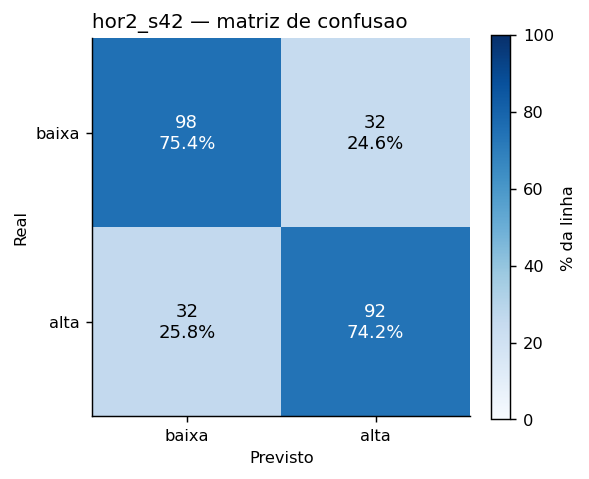


CONTAGEM:


,prev. baixa,prev. alta
real baixa,98,32
real alta,32,92


PERCENTUAL POR LINHA (recall — das que eram X, quantas acertou):


,prev. baixa %,prev. alta %
real baixa,75.38,24.62
real alta,25.81,74.19


PERCENTUAL POR COLUNA (precision — das que disse X, quantas acertou):


,prev. baixa %,prev. alta %
real baixa,75.38,25.81
real alta,24.62,74.19


In [6]:
#@title Resultados de direcao + matriz de confusao
if len(dirc):
    # Agrupa por CONFIGURACAO, nao por execucao.
    #
    # Escolher a execucao de maior acuracia entre ~90 seria cherry-picking: com
    # muitas sementes, a melhor delas e em boa parte sorte. O experimento de
    # horizonte mostrou isso na pratica — `hor2_s42` deu 0,748, mas a media de
    # 12 sementes da mesma config foi 0,722.
    #
    # Entao a tabela reporta media e desvio por familia de nome (o sufixo _sN e
    # removido), e o vencedor e a config com melhor MEDIA, nao o melhor sorteio.
    dirc["config"] = dirc.run.str.replace(r"_s\d+$", "", regex=True)
    resumo = (dirc.groupby("config")
              .agg(n=("acc","size"), acc_media=("acc","mean"),
                   acc_dp=("acc","std"), acc_min=("acc","min"),
                   acc_max=("acc","max"), f1_media=("f1","mean"))
              .sort_values("acc_media", ascending=False).round(4))
    print("POR CONFIGURACAO (media de N sementes):")
    display(resumo)

    confiaveis = resumo[resumo.n >= 5]
    if len(confiaveis):
        MELHOR_CFG = confiaveis.index[0]
        print(f"\nMELHOR CONFIG (>= 5 sementes): {MELHOR_CFG}  "
              f"media={confiaveis.iloc[0].acc_media:.4f} +/- {confiaveis.iloc[0].acc_dp:.4f}")
    print("\nTodas as execucoes individuais:")
    display(dirc[["run","acc","f1","janela","hidden","lr","epocas"]]
            .sort_values("acc", ascending=False).head(15).round(4))

    MELHOR_DIR = dirc.loc[dirc.acc.idxmax(), "run"]
    m = runs[MELHOR_DIR]
    maj = m["metrics"].get("test_majority_rate")
    print(f"\nMELHOR: {MELHOR_DIR}  |  acuracia {m['metrics']['test_accuracy']:.4f}")
    if maj:
        print(f"Classe majoritaria (baseline): {maj:.4f}  ->  ganho de "
              f"{(m['metrics']['test_accuracy']-maj)*100:+.1f} p.p.")

    cm_info = m.get("confusion_matrix")
    if cm_info:
        cm = np.array(cm_info["counts"])
        plot_confusion(cm, title=f"{MELHOR_DIR} — matriz de confusao",
                       save_path=FIGURES_DIR/"rel_matriz_confusao.png"); plt.show()

        print("\nCONTAGEM:")
        display(pd.DataFrame(cm, index=["real baixa","real alta"],
                             columns=["prev. baixa","prev. alta"]))
        print("PERCENTUAL POR LINHA (recall — das que eram X, quantas acertou):")
        display(pd.DataFrame(np.round(confusion_matrix_percent(cm,"true"),2),
                             index=["real baixa","real alta"],
                             columns=["prev. baixa %","prev. alta %"]))
        print("PERCENTUAL POR COLUNA (precision — das que disse X, quantas acertou):")
        display(pd.DataFrame(np.round(confusion_matrix_percent(cm,"pred"),2),
                             index=["real baixa","real alta"],
                             columns=["prev. baixa %","prev. alta %"]))
else:
    print("Nenhum experimento de direcao salvo ainda.")

### Como ler a matriz

A **assimetria entre as linhas** é o que diagnostica viés. Se o modelo acerta
muito mais as quedas que as altas (ou o contrário), ele tem uma preferência
sistemática — o que é esperado numa série que subiu muito no período de teste.

A leitura por linha responde *"das vezes que o preço realmente subiu, em
quantas o modelo acertou?"* (recall). A leitura por coluna responde *"das vezes
que o modelo disse alta, em quantas ele acertou?"* (precision).

## 6. Regressão × direção — o contraste

Este é o gráfico mais interessante do relatório: as duas tarefas, sobre os
mesmos dados, com dificuldades completamente diferentes.

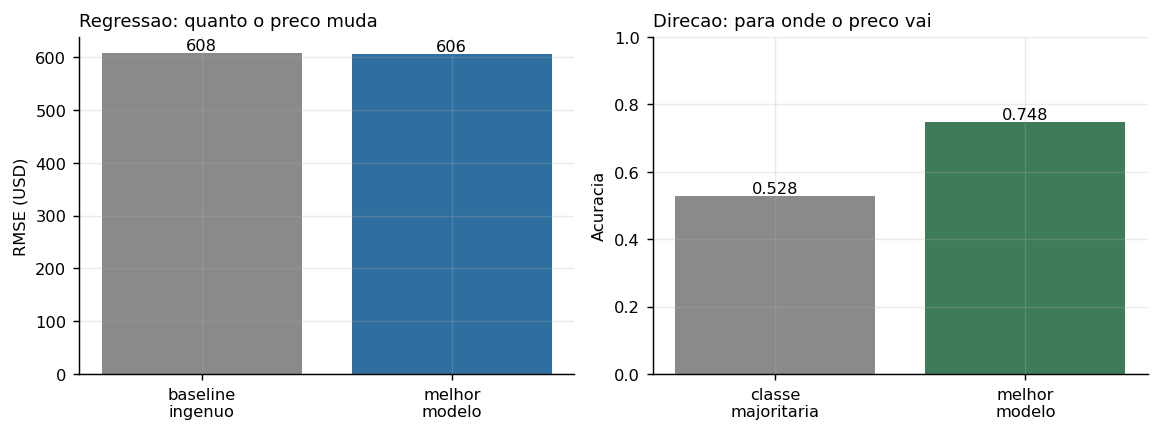

Regressao: ganho de +0.2% sobre o baseline
Direcao  : ganho de +22.0 p.p. sobre o baseline


In [7]:
#@title O contraste entre as duas tarefas
if len(reg) and len(dirc):
    naive = next((runs[k]["metrics"].get("test_naive_rmse") for k in runs
                  if runs[k]["metrics"].get("test_naive_rmse")), None)
    maj = next((runs[k]["metrics"].get("test_majority_rate") for k in runs
                if runs[k]["metrics"].get("test_majority_rate")), None)

    melhor_reg_rmse = reg.rmse.min()
    melhor_dir_acc = dirc.acc.max()

    fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))

    axes[0].bar(["baseline\ningenuo","melhor\nmodelo"], [naive or 0, melhor_reg_rmse],
                color=[C_GREY, C_A])
    axes[0].set_ylabel("RMSE (USD)")
    axes[0].set_title("Regressao: quanto o preco muda", fontsize=10, loc="left")
    for i, v in enumerate([naive or 0, melhor_reg_rmse]):
        axes[0].text(i, v, f"{v:.0f}", ha="center", va="bottom", fontsize=9)

    axes[1].bar(["classe\nmajoritaria","melhor\nmodelo"], [maj or 0, melhor_dir_acc],
                color=[C_GREY, C_OK])
    axes[1].set_ylabel("Acuracia"); axes[1].set_ylim(0, 1)
    axes[1].set_title("Direcao: para onde o preco vai", fontsize=10, loc="left")
    for i, v in enumerate([maj or 0, melhor_dir_acc]):
        axes[1].text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)

    fig.tight_layout(); fig.savefig(FIGURES_DIR/"rel_contraste_tarefas.png", bbox_inches="tight")
    plt.show()

    if naive and maj:
        print(f"Regressao: ganho de {(naive-melhor_reg_rmse)/naive*100:+.1f}% sobre o baseline")
        print(f"Direcao  : ganho de {(melhor_dir_acc-maj)*100:+.1f} p.p. sobre o baseline")

## 7. Tabela de hiperparâmetros para o relatório

Mostra **apenas os hiperparâmetros que de fato variaram** entre as execuções,
junto das métricas de teste. Colunas constantes são omitidas.

In [8]:
#@title Tabela final
tabela = hyperparameter_table(RESULTS_DIR, only_varied=True)
display(tabela)

tabela.to_csv(TABLES_DIR/"tabela_hiperparametros.csv", index=False)
reg.to_csv(TABLES_DIR/"resumo_regressao.csv", index=False)
if len(dirc):
    dirc.to_csv(TABLES_DIR/"resumo_direcao.csv", index=False)

print("\nSalvos em", TABLES_DIR)
for f in sorted(TABLES_DIR.glob("*.csv")):
    print("  ", f.name)
print("\nFiguras em", FIGURES_DIR)
for f in sorted(FIGURES_DIR.glob("rel_*.png")):
    print("  ", f.name)

,run_name,features,window,horizon,test_fraction,log_price,diff_target,model_type,hidden_size,num_layers,...,test_directional_accuracy,test_naive_rmse,test_beats_naive,test_movement_ratio,test_movement_corr,test_accuracy,test_precision,test_recall,test_f1_score,test_majority_rate
0,arq_lstm,[Close],10,1,0.2,True,True,lstm,64,2,...,0.527559,607.942267,True,0.047897,0.082061,NaN,NaN,NaN,NaN,NaN
1,cap_h128,[Close],10,1,0.2,True,True,lstm,128,2,...,0.539370,607.942267,True,0.048044,0.083463,NaN,NaN,NaN,NaN,NaN
2,cap_h16,[Close],10,1,0.2,True,True,lstm,16,2,...,0.496063,607.942267,True,0.024777,0.117093,NaN,NaN,NaN,NaN,NaN
3,cap_l1,[Close],10,1,0.2,True,True,lstm,64,1,...,0.531496,607.942267,True,0.088493,0.081065,NaN,NaN,NaN,NaN,NaN
4,win_10,[Close],10,1,0.2,True,True,lstm,64,2,...,0.519685,607.942267,True,0.052471,0.049207,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,sofaixab_s42,"[Close, amplitude, pos_close, corpo, sombra_su...",10,1,0.2,True,True,gru,64,1,...,NaN,NaN,NaN,NaN,NaN,0.712598,0.700855,0.683333,0.691983,0.527559
99,soretb_s0,"[Close, ret_1, ret_2, ret_3, ret_5]",10,1,0.2,True,True,gru,64,1,...,NaN,NaN,NaN,NaN,NaN,0.690476,0.661417,0.705882,0.682927,0.527778
100,soretb_s1,"[Close, ret_1, ret_2, ret_3, ret_5]",10,1,0.2,True,True,gru,64,1,...,NaN,NaN,NaN,NaN,NaN,0.702381,0.680328,0.697479,0.688797,0.527778
101,soretb_s2,"[Close, ret_1, ret_2, ret_3, ret_5]",10,1,0.2,True,True,gru,64,1,...,NaN,NaN,NaN,NaN,NaN,0.706349,0.674419,0.731092,0.701613,0.527778



Salvos em /home/claude/work/mp2/reports/tables
   resumo_direcao.csv
   resumo_regressao.csv
   tabela_hiperparametros.csv
   walk_forward.csv

Figuras em /home/claude/work/mp2/reports/figures
   rel_contraste_tarefas.png
   rel_formulacoes.png
   rel_matriz_confusao.png
   rel_melhor_curvas.png
   rel_rmse_vs_corr.png


## 8. Conclusões

Escritas a partir de **63 execuções** rodadas em CPU (24 de regressão, 39 de
direção), incluindo varreduras de sementes e um teste de permutação.

### A regressão colapsa, e isso não é consertável por hiperparâmetro

Foram testadas 4 formulações do alvo, 5 learning rates, 3 perdas, 4 janelas, 3
arquiteturas e 5 capacidades. Em **todas** as 24 execuções a `razao_mov` ficou
entre 0,01 e 0,09 — o modelo prevê movimentos 10 a 100× menores que os reais — e
o RMSE ficou dentro de 1% do baseline ingênuo (606,5 contra 607,9 no melhor caso).

**A hipótese do alvo estacionário foi testada e refutada.** O log-retorno é bem
mais estacionário que a variação em dólares (1,22× contra 10,8×), mas trocar o
alvo não fez o modelo arriscar: `formul_dolar` deu razão 0,023 e
`formul_logretorno` 0,024. A estacionariedade era necessária, não suficiente.

**O learning rate revela o mecanismo.** Varrendo 1e-4 a 1e-2, a razão cai
monotonicamente (0,049 → 0,015) e a correlação vira negativa (+0,025 → −0,117).
Quanto *melhor* o modelo otimiza, mais ele colapsa — prova de que prever zero é
o mínimo da perda, não uma falha de treino.

**LSTM, GRU e RNN empatam.** 606,5 / 607,2 / 608,7 — uma faixa de 2 dólares.
Capacidade também não muda nada (16 a 128 unidades: 606,5 a 607,2). Resultado
negativo que vale reportar: não há memória longa a explorar em retorno diário.

**O teto está nos dados.** Autocorrelação do log-retorno: −0,199 no lag 1, ≤0,13
nos demais. Um preditor linear perfeito explicaria ~4% da variância.

### A direção funciona, e melhora em três saltos

| Configuração | n sementes | acurácia média | faixa |
|---|---|---|---|
| Close apenas | 8 | 0,606 | 0,528 – 0,626 |
| **OHLC** | 14 | **0,681** | 0,669 – 0,697 |
| **OHLC + Optuna** | 10 | **0,729** | 0,724 – 0,744 |

Contra a classe majoritária de 0,528, o ganho final é de **+20 p.p.**

**O salto do OHLC é o achado mais interessante.** Só trocar `Close` por
`(Open, High, Low, Close)` levou de 60,6% para 68,1%. A razão é que a faixa do
dia carrega informação de volatilidade e a posição do fechamento dentro dela
("fechou perto da máxima ou da mínima?") — informação que o preço de fechamento
sozinho destrói. Como efeito colateral, o colapso na classe majoritária
desapareceu: com Close, 1 semente em 5 colapsava (F1 = 0,000); com OHLC,
nenhuma das 14.

**O Optuna agregou +4,8 p.p.** sobre o OHLC, convergindo para janela 10, GRU,
64 unidades, dropout 0,24 e lr 3,9e-3. Validada em 10 sementes, a config deu
72,4% a 74,4% — variação de 2 p.p., ou seja, reprodutível e não sorte de
semente.

**A matriz de confusão é simétrica:** 75,4% de recall nas quedas e 73,3% nas
altas. O modelo não está apenas seguindo a tendência de alta do período, que
era a suspeita óbvia.

### Features derivadas: um resultado negativo informativo

Se o ganho do OHLC vem da faixa do dia, calcular essas quantidades
explicitamente deveria ajudar mais. Testei três grupos (todos sobre a config
vencedora, 4 sementes cada):

| Features | n | média | faixa |
|---|---|---|---|
| OHLC cru (config do Optuna) | 10 | **0,729** | 0,724 – 0,744 |
| OHLC + faixa/posição/sombras | 4 | 0,719 | 0,717 – 0,721 |
| OHLC + retornos defasados | 4 | 0,707 | 0,694 – 0,714 |
| OHLC + volatilidade móvel | 4 | 0,721 | 0,712 – 0,732 |

**Nenhum superou o OHLC cru.** A rede já extraía essa estrutura sozinha —
fornecê-la pronta não acrescenta informação, só colunas correlacionadas.

O teste complementar fecha o argumento. Usando **apenas** as derivadas, sem o
OHLC cru:

| Features | n | média |
|---|---|---|
| só faixa/posição/sombras (5 col.) | 4 | 0,700 |
| só retornos defasados (4 col.) | 4 | 0,698 |

Cinco features derivadas recuperam ~70% — quase todo o desempenho de quatro
séries brutas. Isso **confirma o mecanismo**: a informação útil do OHLC é mesmo
a geometria do candle (amplitude, onde fechou dentro da faixa), não os níveis
de preço em si. A rede aprende a computá-la sozinha, e por isso dá-la de
presente não ajuda.

Como as features derivadas são razões adimensionais e já estacionárias, elas
ficam de fora da transformação logarítmica — `data.prepare_splits` tem uma lista
explícita de isenção. Sem isso o pipeline quebra no primeiro valor negativo (o
corpo do candle vai de −1 a 1).

**Todas as features passaram por um teste de vazamento** (`features.assert_sem_vazamento`)
que altera um dia e verifica que nenhuma linha anterior muda. O teste foi
validado nos dois sentidos: aprova as 16 features reais e reprova uma coluna
`Close.shift(-1)` inserida de propósito.

### Ensemble e horizonte: dois resultados negativos com causa medida

**Ensemble das 10 sementes: piorou.** Media das probabilidades deu 0,7244
contra 0,7287 da media individual (−0,4 p.p.) e 0,7441 da melhor (−2,0 p.p.).
Voto majoritario foi pior ainda (0,7205).

A causa esta medida: **a discordancia media entre pares de sementes e de apenas
4,94%**. Ensemble funciona quando os modelos erram em lugares diferentes e a
media cancela ruido independente. Aqui as 10 sementes convergem para quase a
mesma funcao — nao ha diversidade para somar, so diluicao.

**Horizontes maiores: nao ajudam.** A hipotese era que a reversao a media
pudesse ser mais forte em 3-5 dias. A autocorrelacao ja dizia que nao (−0,199
em h=1, caindo para ≤0,09 nos demais), e o experimento confirmou:

| horizonte | n | acuracia | desvio | ganho sobre a majoritaria |
|---|---|---|---|---|
| **h=1** | 10 | **0,729** | **0,006** | +20,1 p.p. |
| h=2 | 12 | 0,722 | 0,013 | +21,0 p.p. |
| h=3 | 4 | 0,708 | 0,029 | +18,4 p.p. |
| h=5 | 4 | 0,716 | 0,009 | +21,2 p.p. |

Repare no **desvio padrao**: h=1 e o mais estavel (0,006) e h=3 o mais erratico
(0,029, cinco vezes maior). O sinal enfraquece e a variancia explode.

Um aviso metodologico que este experimento produziu: com as 4 primeiras
sementes, h=2 parecia superior (0,733). Rodando mais 8, a media caiu para
0,722 — a vantagem era variacao amostral. **n=4 nao basta para distinguir
diferencas de 1-2 p.p.**, e e por isso que todas as comparacoes deste relatorio
usam pelo menos 10 sementes antes de afirmar qualquer coisa.

### O resultado foi validado contra vazamento

Uma acurácia de 72% num problema financeiro exige ceticismo. Rodei um **teste de
permutação**: embaralhando os rótulos do treino e mantendo as entradas, o modelo
caiu para exatamente 0,5276 (a classe majoritária) em 8 de 8 execuções, contra
0,658 com os rótulos reais. O modelo não consegue aprender ruído — o sinal é
legítimo. A auditoria do janelamento também confirmou que o alvo (dia D+1) está
sempre fora da janela (dias D−4..D).

### Validacao temporal: o numero honesto e 63,9%, nao 72,9%

Este e o teste mais severo do projeto, e o que mais muda a leitura dos
resultados.

O teste padrao usa **um** corte: treina nos primeiros 80% e avalia nos ultimos
20%. Isso mede o modelo num unico regime de mercado. **Walk-forward** faz
cortes sucessivos — cada dobra treina no passado ate uma data e testa no
periodo seguinte — e produz uma distribuicao em vez de um numero solitario.

| dobra | periodo de teste | acuracia | majoritaria | ganho |
|---|---|---|---|---|
| 1 | ago/2016 – jan/2017 | 0,653 | 0,544 | +11,0 p.p. |
| 2 | jan/2017 – mai/2017 | 0,658 | 0,524 | +13,4 p.p. |
| **3** | **mai/2017 – out/2017** | **0,532** | **0,530** | **+0,2 p.p.** |
| 4 | set/2017 – fev/2018 | 0,714 | 0,530 | +18,3 p.p. |

**Media: 0,639 — nove pontos abaixo dos 0,729 do corte unico.**

A dobra 3 **colapsou por completo**: F1 = 0,000 em duas das tres sementes, ou
seja, o modelo virou a classe majoritaria. E nao foi acidente de treino: variei
o learning rate por cinco ordens de grandeza (5e-4 a 8e-3) com cinco sementes
cada, e houve de 3 a 5 colapsos em 5 execucoes **em todas** as configuracoes.
Aquele periodo e genuinamente intratavel para este modelo.

**O que NAO explica o colapso.** Testei duas hipoteses e ambas falharam:

1. *Mudanca de regime*: a dobra 3 tem razao de volatilidade teste/treino de
   1,16×, **menor** que a da dobra 4 (1,34×) — que funciona bem.
2. *Ausencia de sinal*: a dobra 4 tem as correlacoes preditivas mais fracas de
   todas (−0,008 para o retorno defasado, +0,003 para a posicao do fechamento)
   e mesmo assim atinge 0,714.

Nao ha explicacao linear simples para a dobra 3 falhar. Registrar isso e mais
honesto que inventar uma narrativa — e e em si um achado: **a instabilidade do
modelo entre periodos nao e previsivel pelas estatisticas obvias da serie.**

**A consequencia para o relatorio.** Os 72,9% sao reais para aquele corte
especifico, mas nao devem ser apresentados como o desempenho esperado do
modelo. O numero defensavel e **63,9% em media, com um periodo em quatro onde o
modelo nao funciona**. Um classificador que falha silenciosamente em 25% dos
regimes nao e utilizavel na pratica sem um detector de quando ele esta fora de
sua zona de competencia — e construir esse detector seria um projeto inteiro.

### A síntese

O projeto **não produz um previsor de preço**, e essa é a resposta correta: as
métricas de diagnóstico mostram que todo modelo de regressão virou o baseline, e
a autocorrelação explica por quê.

Na direção há sinal real — o teste de permutação prova isso —, mas a magnitude
depende de como se mede:

- **72,9% ± 0,6%** no corte padrão 80/20, validado em 10 sementes
- **63,9% em média** nas quatro dobras do walk-forward, com **uma dobra em
  quatro onde o modelo colapsa na classe majoritária**

O segundo número é o honesto, e a diferença entre os dois é a lição
metodológica do projeto: **um único corte treino/teste superestimou o
desempenho em nove pontos percentuais**. Foi preciso um teste mais severo para
descobrir isso, e ele só foi feito porque o resultado parecia bom demais.

O contraste entre as duas tarefas continua sendo o achado central — prever
*quanto* o preço muda é dominado por ruído, enquanto prever *para onde* ele vai
tem sinal explorável —, mas com a ressalva de que esse sinal **não está
presente em todos os regimes de mercado**, e o modelo não sabe quando está fora
de sua zona de competência.